In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import time
import sys
import pandas as pd
import importlib
sys.path.append('..')
import plot_settings
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import torch


colors = plot_settings.colors()

sys.path.append('../nn_model')
import nn_model_lib as _lib
def import_reload():
    plot_settings.apply()
from nn_model_lib import *
import_reload()

import warnings
warnings.filterwarnings("ignore", message=".*__array_wrap__.*")

# Importing data

In [2]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [3]:
def read_raw_data(file_name, pulse=False):

    if pulse:
        df = pd.read_csv(
        f"raw_pulse/{file_name}.txt",
        sep=r'\s+',
        comment="%",
        header=None
    )
        df.columns = ['u_par','C','t','V','I_dummy','F','u','Ue','soc','I']
    else:
        df = pd.read_csv(
        f"raw_CC/{file_name}.txt",
        sep=r'\s+',
        comment="%",
        header=None
    )
        df.columns = ['u_par', 'C', 't', 'V', 'I', 'F', 'u', 'Ue','soc','I_dummy']
    return df

def read_data(file_name):
    df = pd.read_csv(
        f"{file_name}.txt",
        sep=';',
        comment="%"
    )
    return df

def group_trajectories(df):
    """
    Group trajectories by unique combinations of 'C' and 'u_par'.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with columns 'C' and 'u_par'.

    Returns
    -------
    pd.DataFrame
        DataFrame with an added 'trajectory' column indicating group membership.
    """
    df['trajectory'] = df.groupby(['C', 'u_par'], sort=False).ngroup()
    return df

def scaling(df, charge = False):

    '''
    To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m
    Rescales: 
        Displacement: from m to 10*µm
        Force:        from N to GN
    '''

    df['u'] = df['u'] * 1e5
    df['F'] = df['F'] * 1e-9
    df['eta'] = df['Ue'] - df['V']
    if charge:
        df['eta'] = - df['eta'] 
    return df

def preprocess_data(file_name,Pulse = True):
    df = group_trajectories(read_raw_data(file_name,pulse = Pulse))
    df = scaling(df)
    return df
    
def save_data(df, file_name_mod,pølse=False):
    df = df.drop(columns=['I_dummy'])
    if pølse:
        df.to_csv(f'polished_pulse/{file_name_mod}.txt', index=False, sep=';')
    elif pølse == None:
        df.to_csv(f'{file_name_mod}.txt', index=False, sep=';')
    elif pølse == False:
        df.to_csv(f'polished_CC/{file_name_mod}.txt', index=False, sep=';')
    

<>:49: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\D'
/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_35506/3725743778.py:49: SyntaxWarning: invalid escape sequence '\D'
  To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m


In [ ]:
## Test save example on full cycle data
path_pulse = f'full_cycles'
data = preprocess_data(path_pulse, Pulse = True)
save_data(data, 'polished_pulse/cycles', pølse=None)


#data_test = read_data('crate2.5_usweep_pulse')
#plt.plot(data_test['t'], data_test['I'], label='V')

#data = read_data('polished_CC/merged_CC_hyper')

In [ ]:
def merge_runs(
    n_runs,
    pulse=None,
    add_run_id=False,
    shuffle_trajectories=False,
    random_state=None
):
    """
    Merge multiple run files into one dataframe.
    """

    run_configs = []

    # Add pulse runs
    if pulse is True or pulse is None:
        for n in range(1, n_runs + 1):
            run_configs.append({
                "name": f"data_pulse_hyper_{n}",
                "pulse": True
            })

    # Add DC/non-pulse runs
    if pulse is False or pulse is None:
        for n in range(1, n_runs + 1):
            run_configs.append({
                "name": f"data_CC_hyper_{n}",
                "pulse": False
            })

    print("Merging runs:")
    for cfg in run_configs:
        print(f"  {cfg['name']} (pulse={cfg['pulse']})")

    frames = []

    for cfg in run_configs:

        df = preprocess_data(cfg["name"], Pulse=cfg["pulse"])

        if add_run_id:
            df["run_id"] = cfg["name"]

        df["pulse"] = cfg["pulse"]

        frames.append(df)

    merged = pd.concat(frames, ignore_index=True)

    # Remove duplicates
    merged = merged.drop_duplicates(subset=['C', 'u_par', 't'])

    # Initial trajectory labels
    merged['trajectory'] = (
        merged.groupby(['C', 'u_par'], sort=False).ngroup()
    )

    # ---------------------------------------------------
    # Shuffle whole trajectories
    # ---------------------------------------------------
    if shuffle_trajectories:

        rng = np.random.default_rng(random_state)

        # Unique trajectory IDs
        traj_ids = merged['trajectory'].unique()

        # Shuffle trajectory order
        shuffled_ids = rng.permutation(traj_ids)

        shuffled_frames = []

        for traj_id in shuffled_ids:

            traj_df = merged[merged['trajectory'] == traj_id]

            # Keep time ordering inside trajectory
            traj_df = traj_df.sort_values('t')

            shuffled_frames.append(traj_df)

        merged = pd.concat(shuffled_frames, ignore_index=True)

        # -----------------------------------------------
        # Recreate trajectory IDs AFTER shuffling
        # so they become ordered 0,1,2,3,...
        # in the shuffled order
        # -----------------------------------------------
        merged = merged.drop(columns=['trajectory'])

        merged['trajectory'] = (
            merged.groupby(['C', 'u_par'], sort=False).ngroup()
        )

    return merged




# combo_half = read_data('polished_combo/combo_half')

# combo_high = combo_half[combo_half['C']>=2]
# combo_low1 = combo_half[combo_half['C'] == 0.61]
# combo_low2 = combo_half[combo_half['C'] == 1]

# combo_high.describe()

# combo_high.to_csv(f'polished_combo/combo_high.txt', index=False, sep=';')

## Data Exploration

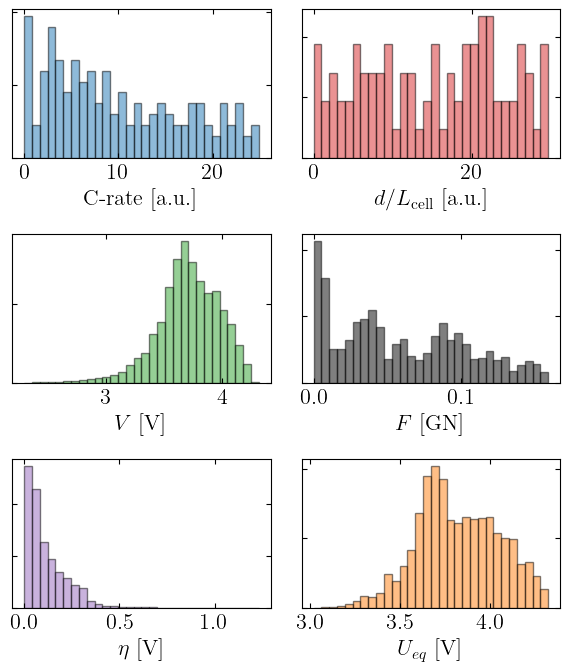

In [10]:
f, ax = plt.subplots(3,2,figsize=(6, 7))
ax[0,0].hist(np.unique(data['I']), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(np.unique(data['u_par']), bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(np.unique(data['F']), bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['Ue'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist((data['eta']), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('C-rate [a.u.]')
ax[0,1].set_xlabel(r'$d/L_{\mathrm{cell}}$ [a.u.]')
ax[1,0].set_xlabel('$V$ [V]')
ax[1,1].set_xlabel('$F$ [GN]')
ax[2,1].set_xlabel('$U_{eq}$ [V]')
ax[2,0].set_xlabel(r'$\eta$ [V]')
#ax[2,0].set_xlabel('$E_{Ue}$')
#ax[2,1].set_xlabel('$d$')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

Text(0, 0.5, '$\\varepsilon_{\\mathrm{vol.}}$ [a.u.]')

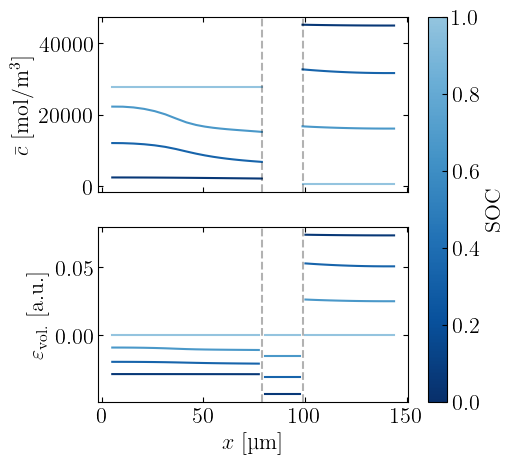

In [7]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
Ln = 7.8733*10; Ls = 20
df_conc = pd.read_csv('concentration_strain_2.csv', comment="%")

base = plt.cm.Blues_r
cmap = LinearSegmentedColormap.from_list(
    "Blues_custom", base(np.linspace(0.0, 0.6, 256)))

df_conc.columns = ['x', 'c_0', 'e0','soc_0','c_1', 'e1','soc_1','c_2', 'e2','soc_2', 'c_3', 'e3','soc_3']
f,ax = plt.subplots(2,1,figsize=(5, 5), sharex=True)
for i in range(4):
    ax[0].plot(df_conc['x'] * 1e6, df_conc[f'c_{i}'], label=f'c_{i}', color=cmap(df_conc[f'soc_{i}'].iloc[0]))
    inds = [df_conc['x'] * 1e6 < Ln -0.1, (df_conc['x'] * 1e6 > Ln) & (df_conc['x'] * 1e6 < Ln + Ls-0.1), df_conc['x'] * 1e6 > Ln + Ls+0.1]
    for j in inds:
        ax[1].plot(df_conc['x'].values[j] * 1e6, df_conc[f'e{i}'].values[j], label=f'e_{i}', color=cmap(df_conc[f'soc_{i}'].iloc[0]))
plt.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=cmap), ax=ax, label='SOC')
ax[0].axvline(Ln, color='black', linestyle='--', alpha = 0.3)
ax[0].axvline(Ln + Ls, color='black', linestyle='--', alpha = 0.3)

ax[1].axvline(Ln, color='black', linestyle='--', alpha = 0.3)
ax[1].axvline(Ln + Ls, color='black', linestyle='--', alpha = 0.3)
ax[0].set_ylabel(r'$\bar{c}$ [mol/m$^3$]')
ax[1].set_xlabel('$x$ [µm]')
ax[1].set_ylabel(r'$\varepsilon_{\mathrm{vol.}}$ [a.u.]')
# plt.savefig('data/concentration_strain_2.pdf', bbox_inches='tight')

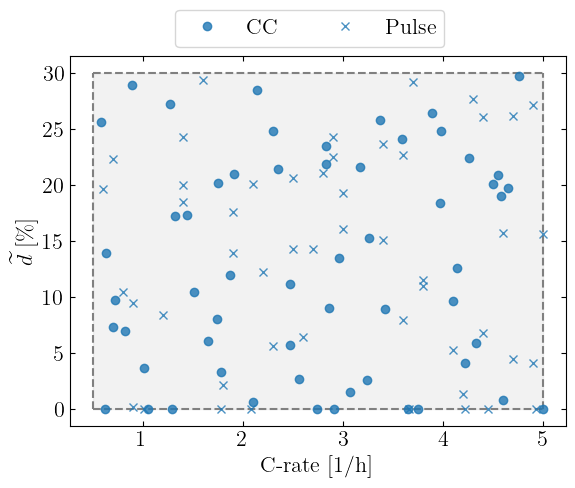

In [8]:
data = combo_half
df_CC = data[data['pulse'] == False]
df_pulse = data[data['pulse'] == True]

plt.xlabel('C-rate [1/h]')
plt.ylabel(r'$\widetilde{d}$ [\%]')
plt.vlines(0.5,0,30, color='gray', linestyle='--')
plt.vlines(5,0,30, color='gray', linestyle='--')
plt.hlines(0,0.5,5, color='gray', linestyle='--')
plt.hlines(30,0.5,5, color='gray', linestyle='--')
plt.fill_between([0.5, 5], 0, 30, color='gray', alpha=0.1)

u_C_pairs = df_CC.loc[df_CC['t'] == 0, ['u_par', 'C']]
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o', color = 'tab:blue', label = 'CC', alpha=0.8)
u_C_pairs = df_pulse.loc[df_pulse['t'] == 0, ['u_par', 'C']]
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'],'x', color = 'tab:blue', label = 'Pulse', alpha=0.8)
fig = plt.gcf()
fig.legend(ncols = 2, loc='upper center', bbox_to_anchor=(0.5, 1))

# plt.savefig('data_figs/C_u_par_distribution.pdf', bbox_inches='tight')

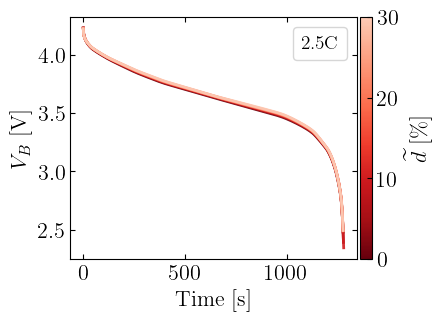

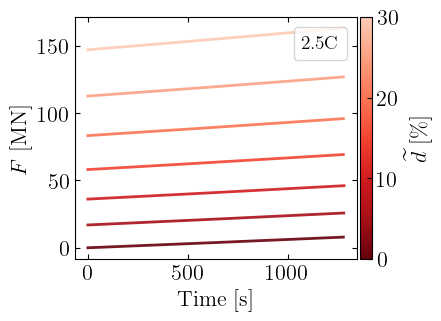

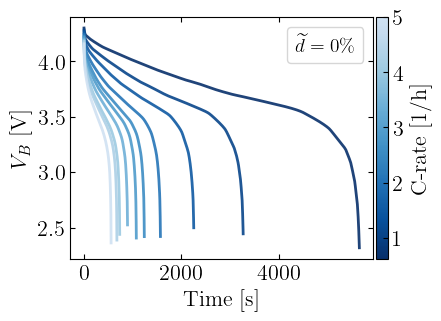

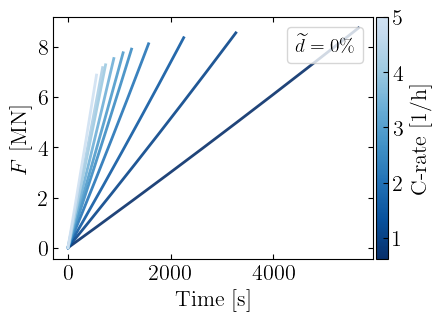

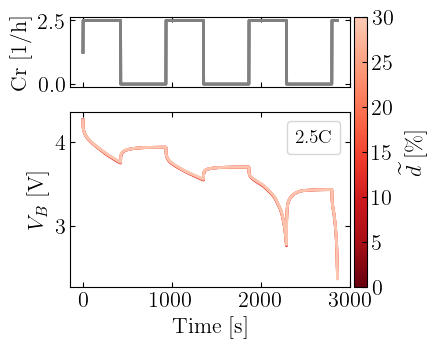

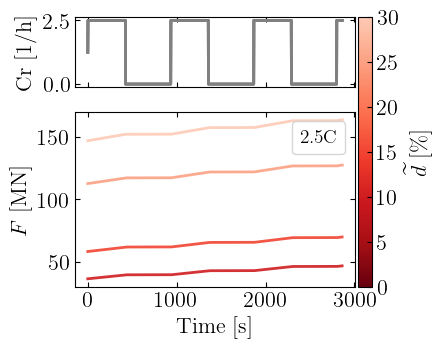

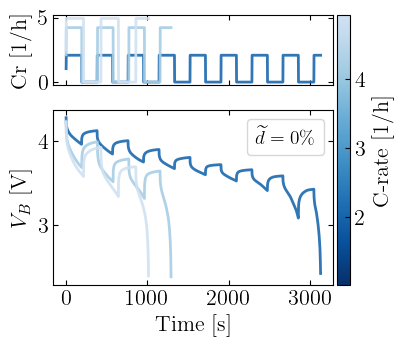

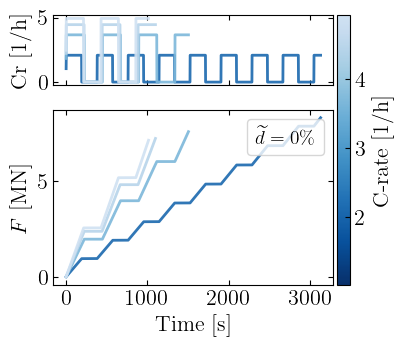

In [9]:
def plot_data_report(trajs, *, sort='C_rate', present='V', n_show=5, pulse=False,
                     Q0=17921.57581):
    """Two-panel (pulse) or single-panel (CC) raw-data plot.
    
    pulse=True  → current panel (top, compact) + voltage panel (bottom),
                  shared colorbar across both.
    pulse=False → voltage panel only, with a fixed-value tag showing the
                  constant of the non-swept variable.
    """
    if sort == 'C_rate':
        trajs_sorted = sorted(trajs, key=lambda tr: tr['C'])
        vals_arr = np.array([tr['C'] for tr in trajs_sorted])
        bar_name = 'C-rate [1/h]'
    elif sort == 'u_per':
        trajs_sorted = sorted(trajs, key=lambda tr: tr['u_per'])
        vals_arr = np.array([tr['u_per'] for tr in trajs_sorted])
        bar_name = r'$\widetilde{d}$ [\%]'
    else:
        raise ValueError(f"sort must be 'C_rate' or 'u_per', got {sort!r}")
    norm = Normalize(vmin=vals_arr.min(), vmax=vals_arr.max())

    if n_show is None or n_show >= len(trajs_sorted):
        trajs_plot = trajs_sorted
    else:
        start = 2 if pulse else 0
        idx = np.unique(np.linspace(start, len(trajs_sorted) - 1, n_show).round().astype(int))
        trajs_plot = [trajs_sorted[i] for i in idx]

    base = plt.cm.Blues_r
    cmap = LinearSegmentedColormap.from_list(
        "Blues_custom", base(np.linspace(0.0, 0.8, 256)))
    base = plt.cm.Reds_r
    cmap_r = LinearSegmentedColormap.from_list(
        "Reds_custom", base(np.linspace(0.0, 0.8, 256)))

    # ── layout ──────────────────────────────────────────────────────────
    if pulse:
        fig, ax = plt.subplot_mosaic(
            [['current'], ['voltage']],
            figsize=(4.3, 3.5),
            # figsize=(4.3, 3.64),
            height_ratios=[0.4, 1.0],
            sharex=True, 
            #constrained_layout=True,
        )
        ax_i, ax_v = ax['current'], ax['voltage']
    else:
        fig, ax_v = plt.subplots(figsize=(4.3, 3.1), constrained_layout=True)
        ax_i = None

    I_to_C = 3600.0 / Q0

    # ── plot ────────────────────────────────────────────────────────────
    for tr in trajs_plot:
        bar_val = float(tr['C']) if sort == 'C_rate' else float(tr['u_per'])
        color = cmap(norm(bar_val)) if sort == 'C_rate' else cmap_r(norm(bar_val))

        t = np.arange(tr['T'])
        V = tr['V'].numpy() if hasattr(tr['V'], 'numpy') else np.asarray(tr['V'])
        F = tr['F'].numpy() if hasattr(tr['F'], 'numpy') else np.asarray(tr['F'])
        if present == 'V':
            ax_v.plot(t, V, color=color, lw=2, alpha=0.9)
        elif present == 'F':
            ax_v.plot(t, F * 1e3, color=color, lw=2, alpha=0.9)

        if pulse and 'I_seq' not in tr:
            raise ValueError(
                "pulse=True but trajectory has no 'I_seq' — did you use prepare_data instead of prepare_pulse_data?")
        if pulse:
            if 'I_seq' in tr:
                I = tr['I_seq'].numpy() if hasattr(tr['I_seq'], 'numpy') else np.asarray(tr['I_seq'])
            else:
                I = tr['I'] * np.ones_like(t)
            ax_i.plot(t, I * I_to_C, color=color if sort == 'C_rate' else 'gray', lw=2, alpha=0.9)

    if present == 'V':
        ax_v.set_ylabel(r'$V_B$ [V]')
    elif present == 'F':
        ax_v.set_ylabel(r'$F$ [MN]')
    ax_v.set_xlabel('Time [s]')

    # Fixed-value tag — value of the variable not being swept
    first = trajs_plot[0]
    if sort == 'u_per':
        tag = fr'${float(first["C"]):g}$C'
    else:   # sort == 'C_rate'
        tag = fr'$\widetilde{{d}} = {float(first["u_per"]):g}\%$'

    ax_v.legend(handles=[plt.Line2D([0], [0], color='none', label=tag)], loc='upper right',
                 frameon=True, handlelength=0, handletextpad=0, fontsize=14)
    if pulse:
        ax_i.set_ylabel('Cr [1/h]')
        # ax_v.set_xlim(-100, 3200)
    # else:
    #     ax_v.legend(handles=[plt.Line2D([0], [0], color='none', label=tag)], loc='upper right', frameon=True, handlelength=0, handletextpad=0)
    

    sm = ScalarMappable(cmap=cmap if sort == 'C_rate' else cmap_r, norm=norm)
    sm.set_array([])
    cbar_ax = [ax_i, ax_v] if pulse else ax_v
    fig.colorbar(sm, ax=cbar_ax, label=bar_name, location='right', pad=0.01)
    

    # for pulses u_per
    # ax_v.set_xlim(-100, 3200)

    return fig

# ––––––– CC –––––––––––––––––––––––––––––––––––––––––––––––––––––
data_cc = read_data('polished_CC/crate2.5_usweep')
trajs = prepare_data(data_cc)
plot_data_report(trajs, sort='u_per', present='V', n_show=10)
# plt.savefig('data_figs/CC_u_sweep_V.pdf', bbox_inches='tight')
plt.show()

plot_data_report(trajs, sort='u_per', present='F', n_show=10)
# plt.savefig('data_figs/CC_u_sweep_F.pdf', bbox_inches='tight')
plt.show()

data_cc_old = read_data('polished_CC/merged_CC_hyper')
trajs_d0 = prepare_data(data_cc_old[data_cc_old['u_par'] == 0])
plot_data_report(trajs_d0, sort='C_rate', n_show=10)
# plt.savefig('data_figs/CC_c_sweep_V.pdf', bbox_inches='tight')
plt.show()

plot_data_report(trajs_d0, sort='C_rate', present='F', n_show=10)
# plt.savefig('data_figs/CC_c_sweep_F.pdf', bbox_inches='tight')
plt.show()

# # –––––––– Pulse –––––––––––––––––––––––––––––––––––––––––––––––––––
data_pulse = read_data('polished_pulse/crate2.5_usweep_pulse')
pulse_trajs = prepare_pulse_data(data_pulse)
plot_data_report(pulse_trajs, sort='u_per', present='V', n_show=4, pulse=True)
# plt.savefig('data_figs/pulse_u_sweep_V.pdf', bbox_inches='tight')
plt.show()

data_pulse = read_data('polished_pulse/crate2.5_usweep_pulse')
pulse_trajs = prepare_pulse_data(data_pulse)
plot_data_report(pulse_trajs, sort='u_per', present='F', n_show=4, pulse=True)
# plt.savefig('data_figs/pulse_u_sweep_F.pdf', bbox_inches='tight')
plt.show()

data_pulse_old = read_data('polished_combo/combo_half')
pulse_trajs_d0 = prepare_pulse_data(data_pulse_old[(data_pulse_old['u_par'] == 0) & (data_pulse_old['pulse'] == True)])
plot_data_report(pulse_trajs_d0, sort='C_rate', present='V', n_show=3, pulse=True)
# plt.savefig('data_figs/pulse_c_sweep_V.pdf', bbox_inches='tight')
plt.show()


data_pulse_old = read_data('polished_combo/combo_half')
pulse_trajs_d0 = prepare_pulse_data(data_pulse_old[(data_pulse_old['u_par'] == 0) & (data_pulse_old['pulse'] == True)])
plot_data_report(pulse_trajs_d0, sort='C_rate', present='F', n_show=4, pulse=True)
# plt.savefig('data_figs/pulse_c_sweep_F.pdf', bbox_inches='tight')
plt.show()